# Gradient-Guided Fuzz Test Input Generation (SuT: `MnistCNN`)

In this exercise, we explore **gradient-guided input generation** for deep learning models.

Unlike traditional random fuzzing, this approach uses the model's loss gradient to identify input perturbations that most effectively increase prediction error. Although not purely random, it follows the core idea of fuzzing: automatically generating inputs to uncover unexpected or erroneous behavior.

This technique, known as the **Fast Gradient Sign Method (FGSM)**, illustrates how white-box access enables highly efficient failure discovery in neural networks.

In [23]:
import os, sys

# exercises → unit folder → modules → project_root
MODULES_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
CODE_DIR = os.path.join(MODULES_ROOT, "exercise_artifacts", "code")
MODEL_DIR = os.path.join(MODULES_ROOT, "exercise_artifacts", "model")
DATA_DIR = os.path.join(MODULES_ROOT, "exercise_artifacts", "data")

if CODE_DIR not in sys.path:
    sys.path.append(CODE_DIR)

if MODEL_DIR not in sys.path:
    sys.path.append(MODEL_DIR)

if DATA_DIR not in sys.path:
    sys.path.append(DATA_DIR)

print("Added to sys.path:", CODE_DIR)
print("Added to sys.path:", MODEL_DIR)
print("Added to sys.path:", DATA_DIR)

Added to sys.path: /workspace/modules/exercise_artifacts/code
Added to sys.path: /workspace/modules/exercise_artifacts/model
Added to sys.path: /workspace/modules/exercise_artifacts/data


In [24]:
# Load pre-saved MNIST model
import torch
from mnist_model import load_trained_model
from torchinfo import summary

device = "cuda" if torch.cuda.is_available() else "cpu"

WEIGHTS_PATH = os.path.join(MODEL_DIR, "mnist_model_weights.pt")

model = load_trained_model(WEIGHTS_PATH, device=device)

print("MnistCNN Summary:")
summary(model, input_size=(1, 1, 28, 28), col_names=["input_size", "output_size", "num_params"])

MnistCNN Summary:


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
MnistCNN                                 [1, 1, 28, 28]            [1, 10]                   --
├─Conv2d: 1-1                            [1, 1, 28, 28]            [1, 8, 28, 28]            80
├─Conv2d: 1-2                            [1, 8, 14, 14]            [1, 16, 14, 14]           1,168
├─Linear: 1-3                            [1, 784]                  [1, 32]                   25,120
├─Linear: 1-4                            [1, 32]                   [1, 10]                   330
Total params: 26,698
Trainable params: 26,698
Non-trainable params: 0
Total mult-adds (M): 0.32
Input size (MB): 0.00
Forward/backward pass size (MB): 0.08
Params size (MB): 0.11
Estimated Total Size (MB): 0.19

In [25]:
# Load pre-saved MNIST subsets (using DATA_DIR defined above)
test_data = torch.load(os.path.join(DATA_DIR, "mnist_test_200.pt"))

test_images, test_labels = test_data["images"], test_data["labels"]

print(f"Test:  {test_images.shape}, {test_labels.shape}")

Test:  torch.Size([200, 1, 28, 28]), torch.Size([200])


## Baseline Prediction

Before applying any perturbations, we evaluate the model's accuracy on the original test inputs to establish a baseline.

Baseline Accuracy: 91.00% (182/200)


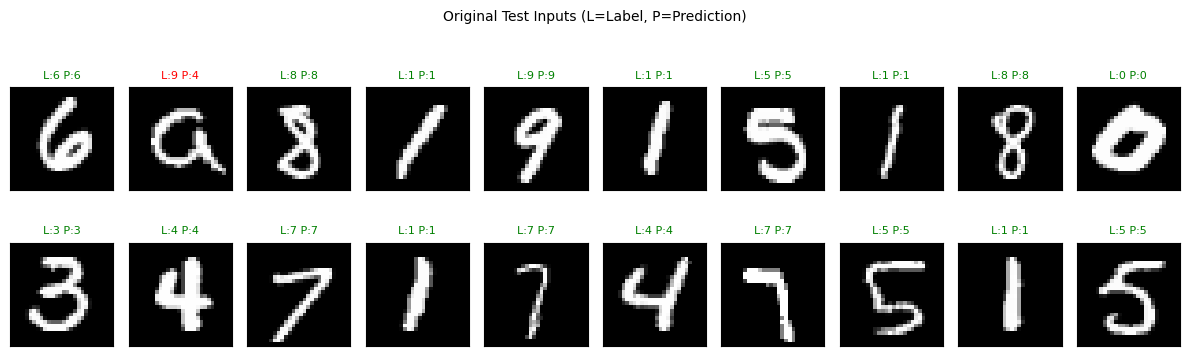

In [26]:
# Calculate baseline accuracy and visualize first 20 test inputs
import matplotlib.pyplot as plt

# Evaluate model on all test inputs
model.eval()
with torch.no_grad():
    test_inputs = test_images.to(device)
    outputs = model(test_inputs)
    predictions = outputs.argmax(dim=1)
    correct = (predictions == test_labels.to(device)).sum().item()
    baseline_accuracy = correct / len(test_labels)

print(f"Baseline Accuracy: {baseline_accuracy:.2%} ({correct}/{len(test_labels)})")

# Visualize first 20 test inputs with predictions
n_display = 20
n_cols = 10
n_rows = (n_display + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.2, n_rows * 2.0))
axes = axes.flatten()

for i in range(n_display):
    ax = axes[i]
    img = test_images[i].squeeze().cpu()
    label = test_labels[i].item()
    pred = predictions[i].item()
    
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.set_xticks([])
    ax.set_yticks([])
    
    # Green title if correct, red if wrong
    color = "green" if pred == label else "red"
    ax.set_title(f"L:{label} P:{pred}", fontsize=8, color=color)

plt.suptitle("Original Test Inputs (L=Label, P=Prediction)", fontsize=10)
plt.tight_layout()
plt.show()

## Computing the Input Gradient

To generate adversarial perturbations, we first compute the gradient of the loss with respect to the input pixels. This gradient indicates which direction to perturb each pixel to maximally increase the loss.

In [27]:
# Compute input gradients for all test images
import torch.nn as nn

# Prepare inputs with gradient tracking
images = test_images.clone().to(device)
labels = test_labels.to(device)
images.requires_grad = True

# Forward pass
model.eval()
outputs = model(images)

# Compute loss w.r.t. true labels
loss = nn.CrossEntropyLoss()(outputs, labels)

# Backpropagate to get gradients w.r.t. input pixels
loss.backward()

# Extract gradients
input_gradients = images.grad.data

print(f"Images shape: {images.shape}")
print(f"Gradients shape: {input_gradients.shape}")
print(f"Gradient range: [{input_gradients.min().item():.4f}, {input_gradients.max().item():.4f}]")

Images shape: torch.Size([200, 1, 28, 28])
Gradients shape: torch.Size([200, 1, 28, 28])
Gradient range: [-0.0034, 0.0036]


## Generating Adversarial Inputs (FGSM)

The **Fast Gradient Sign Method (FGSM)** creates adversarial examples by adding a small perturbation in the direction of the gradient sign:

$$x_{adv} = x + \varepsilon \cdot \text{sign}(\nabla_x L)$$

where $\varepsilon$ controls the perturbation magnitude.

In [28]:
# FGSM: Apply perturbation using pre-computed gradients
# Formula: adversarial = original + ε × sign(gradient)
epsilon = 0.2

# Generate perturbation from gradients (computed above)
perturbations = epsilon * input_gradients.sign()

# Create adversarial images (clamp to valid pixel range [0, 1])
adv_images = torch.clamp(test_images.to(device) + perturbations, 0, 1)

print(f"Epsilon: {epsilon}")
print(f"Original images shape: {test_images.shape}")
print(f"Adversarial images shape: {adv_images.shape}")

Epsilon: 0.2
Original images shape: torch.Size([200, 1, 28, 28])
Adversarial images shape: torch.Size([200, 1, 28, 28])


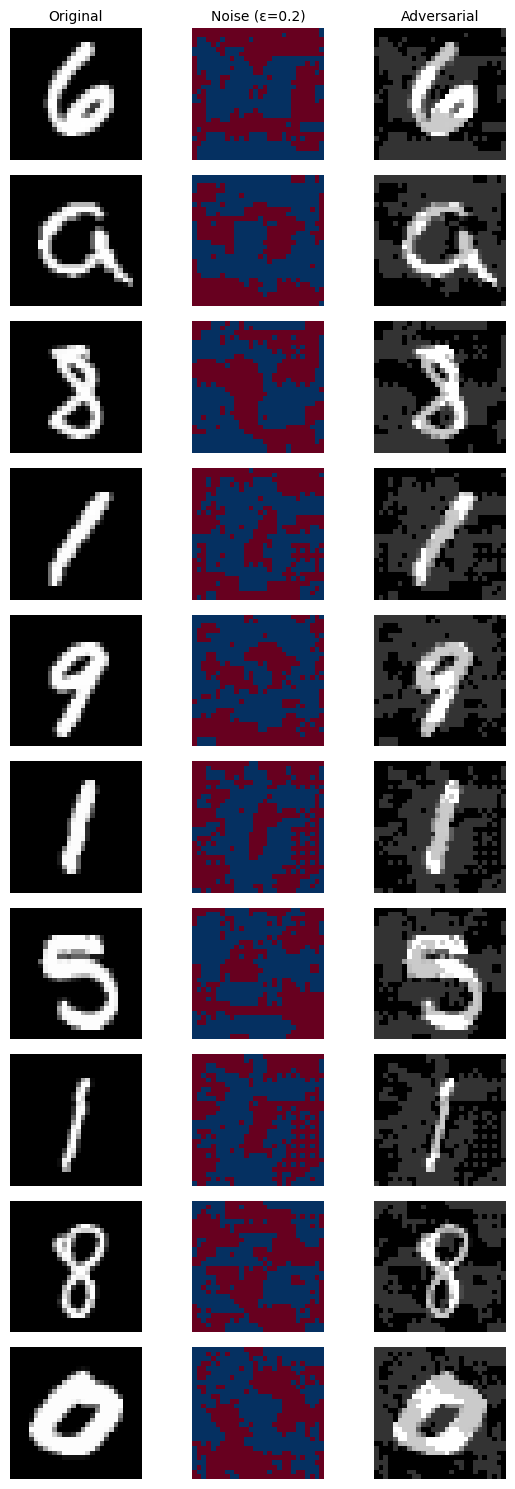

In [29]:
# Visualize: Original, Perturbation, Adversarial (10 rows × 3 columns)
n_display = 10
fig, axes = plt.subplots(n_display, 3, figsize=(6, n_display * 1.5))

for i in range(n_display):
    # Original
    axes[i, 0].imshow(test_images[i].squeeze().cpu(), cmap="gray", vmin=0, vmax=1)
    axes[i, 0].axis("off")
    if i == 0:
        axes[i, 0].set_title("Original", fontsize=10)
    
    # Perturbation (noise)
    pert = perturbations[i].squeeze().cpu()
    axes[i, 1].imshow(pert, cmap="RdBu", vmin=-epsilon, vmax=epsilon)
    axes[i, 1].axis("off")
    if i == 0:
        axes[i, 1].set_title(f"Noise (ε={epsilon})", fontsize=10)
    
    # Adversarial
    axes[i, 2].imshow(adv_images[i].squeeze().cpu(), cmap="gray", vmin=0, vmax=1)
    axes[i, 2].axis("off")
    if i == 0:
        axes[i, 2].set_title("Adversarial", fontsize=10)

plt.tight_layout()
plt.show()

## Evaluating the Attack

We measure the effectiveness of the FGSM attack by comparing accuracy before and after perturbation.

Baseline Accuracy:   91.00% (182/200)
Adversarial Accuracy: 14.50% (29/200)
Accuracy Drop:        76.50%


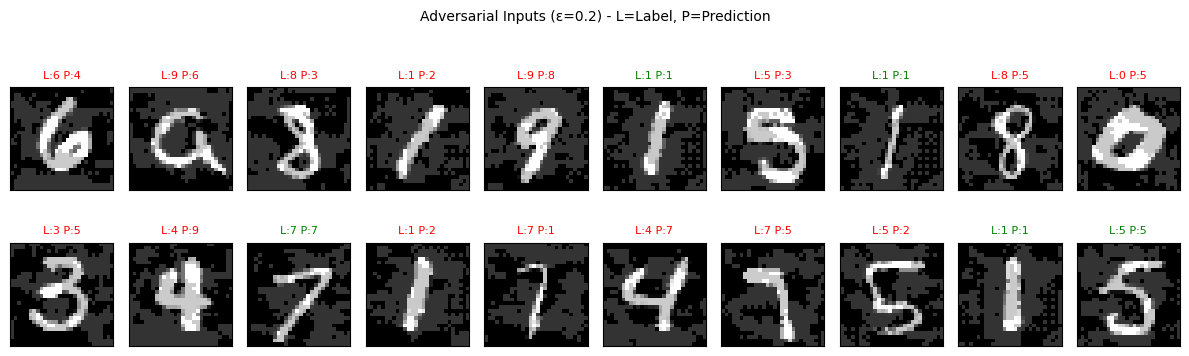

In [30]:
# Evaluate attack: compare accuracy before and after
model.eval()
with torch.no_grad():
    # Accuracy on adversarial images
    adv_outputs = model(adv_images)
    adv_predictions = adv_outputs.argmax(dim=1)
    adv_correct = (adv_predictions == test_labels.to(device)).sum().item()
    adv_accuracy = adv_correct / len(test_labels)

print(f"Baseline Accuracy:   {baseline_accuracy:.2%} ({correct}/{len(test_labels)})")
print(f"Adversarial Accuracy: {adv_accuracy:.2%} ({adv_correct}/{len(test_labels)})")
print(f"Accuracy Drop:        {baseline_accuracy - adv_accuracy:.2%}")

# Visualize first 20 adversarial inputs with predictions
n_display = 20
n_cols = 10
n_rows = (n_display + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.2, n_rows * 2.0))
axes = axes.flatten()

for i in range(n_display):
    ax = axes[i]
    img = adv_images[i].squeeze().cpu()
    label = test_labels[i].item()
    pred = adv_predictions[i].item()
    
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.set_xticks([])
    ax.set_yticks([])
    
    # Green if correct, red if wrong
    color = "green" if pred == label else "red"
    ax.set_title(f"L:{label} P:{pred}", fontsize=8, color=color)

plt.suptitle(f"Adversarial Inputs (ε={epsilon}) - L=Label, P=Prediction", fontsize=10)
plt.tight_layout()
plt.show()

## Neuron Coverage Analysis

Beyond accuracy, we examine how adversarial inputs affect neuron activation patterns compared to clean inputs.

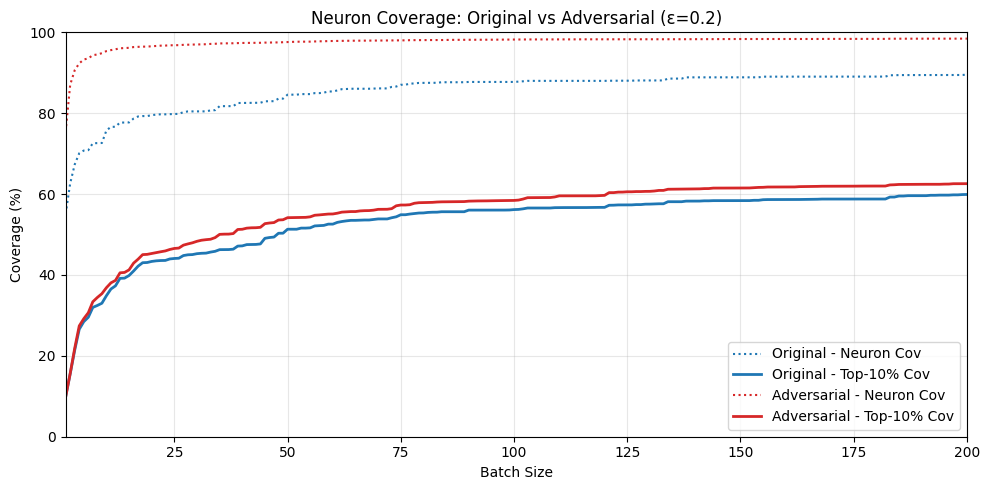

Final Coverages (batch size = 200):
  Original    - Neuron: 89.5%, Top-10%: 59.9%
  Adversarial - Neuron: 98.4%, Top-10%: 62.6%


In [31]:
# Compare neuron coverage: Original vs Adversarial inputs
max_size = len(test_images)
batch_sizes = list(range(1, max_size + 1))

# Storage for coverages
orig_nc, orig_topk = [], []
adv_nc, adv_topk = [], []

with torch.no_grad():
    for size in batch_sizes:
        # Original inputs
        orig_batch = test_images[:size].to(device)
        _, orig_acts = forward_and_capture_relu(model, orig_batch)
        nc, _ = neuron_coverage(orig_acts)
        tk, _ = top_k_neuron_coverage(orig_acts, k=0.1)
        orig_nc.append(nc)
        orig_topk.append(tk)
        
        # Adversarial inputs
        adv_batch = adv_images[:size]
        _, adv_acts = forward_and_capture_relu(model, adv_batch)
        nc, _ = neuron_coverage(adv_acts)
        tk, _ = top_k_neuron_coverage(adv_acts, k=0.1)
        adv_nc.append(nc)
        adv_topk.append(tk)

# Plot: Original (blue), Adversarial (red)
# Neuron coverage (dotted), Top-k coverage (solid)
plt.figure(figsize=(10, 5))

# Original
plt.plot(batch_sizes, [c * 100 for c in orig_nc], 
         linestyle=":", linewidth=1.5, color="tab:blue", label="Original - Neuron Cov")
plt.plot(batch_sizes, [c * 100 for c in orig_topk], 
         linestyle="-", linewidth=2, color="tab:blue", label="Original - Top-10% Cov")

# Adversarial
plt.plot(batch_sizes, [c * 100 for c in adv_nc], 
         linestyle=":", linewidth=1.5, color="tab:red", label="Adversarial - Neuron Cov")
plt.plot(batch_sizes, [c * 100 for c in adv_topk], 
         linestyle="-", linewidth=2, color="tab:red", label="Adversarial - Top-10% Cov")

plt.xlabel("Batch Size")
plt.ylabel("Coverage (%)")
plt.title(f"Neuron Coverage: Original vs Adversarial (ε={epsilon})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(1, max_size)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

# Print summary
print(f"Final Coverages (batch size = {max_size}):")
print(f"  Original    - Neuron: {orig_nc[-1]:.1%}, Top-10%: {orig_topk[-1]:.1%}")
print(f"  Adversarial - Neuron: {adv_nc[-1]:.1%}, Top-10%: {adv_topk[-1]:.1%}")

